In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
#%matplotlib inline

In [17]:
data = np.load("field-aberrations_s7.pkl",allow_pickle=True)

In [18]:
z = np.asarray([x[0] for x in data] )

Text(0.5, 0, 'Zernike mode #')

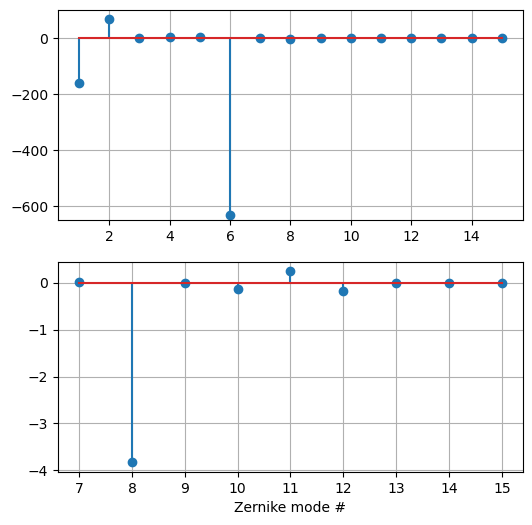

In [124]:
c = np.asarray(data[-1][1])
fig,axs=plt.subplots(nrows=2,figsize=(6,6))
ax = axs[0]
ax.stem(np.arange(1,16),c)
ax.grid()
ax.set_ylim([-650,100])
#ax.set_xlabel("Zernike mode #")
ax=axs[1]
ax.stem(np.arange(7,16),c[6:])
ax.grid()
ax.set_xlabel("Zernike mode #")


Text(0.5, 0, 'Zernike mode #')

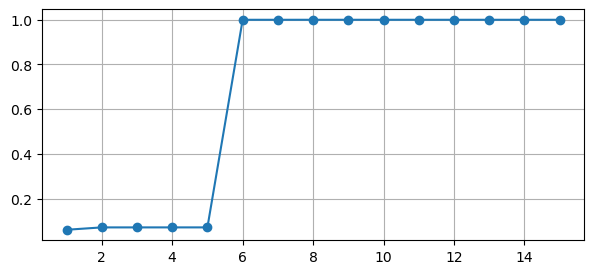

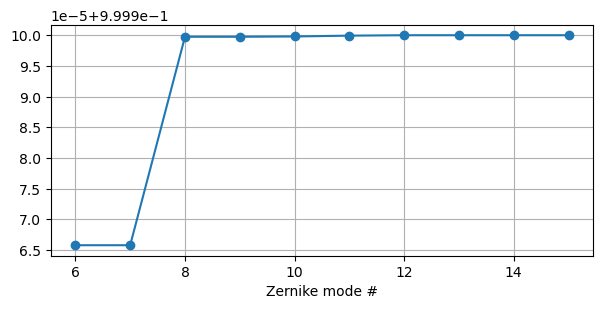

In [125]:
cc = np.cumsum(c*c)/np.sum(c*c)
fig,ax = plt.subplots(figsize=(7,3))
ax.plot(np.arange(1,16),cc,'-o')
ax.grid()
fig,ax = plt.subplots(figsize=(7,3))
ax.plot(np.arange(6,16),cc[5:],'-o')
ax.grid()
ax.set_xlabel("Zernike mode #")

In [126]:
astigmatism = np.asarray([np.hypot(x[1][4],x[1][5]) for x in data] )
#astigmatism = np.asarray([x[1][5] for x in data] )
coma = np.asarray([x[1][7] for x in data] )
spherical = np.asarray([x[1][10] for x in data] )
trefoil = np.asarray([x[1][9] for x in data] )
quadrafoil = np.asarray([x[1][11] for x in data] )

In [127]:
p_astigmatism = np.polyfit(z,astigmatism,2)
p_coma = np.polyfit(z,coma,3)
p_spherical = np.polyfit(z,spherical,2)
p_trefoil = np.polyfit(z,trefoil,3)
p_quadrafoil = np.polyfit(z,quadrafoil,4)

In [128]:
8.365/np.sqrt(p_astigmatism[0]*(180*60/np.pi)**2*1e-9*2*np.sqrt(6) / 2.96887)

23.735369739558305

In [149]:
g = 8.365/25.44
#g = np.sqrt(p_astigmatism[0]*(180*60/np.pi)**2*1e-9*2*np.sqrt(6) / 2.96887)
c222 = g**2 * 2.96887 / ((180*60/np.pi)**2*1e-9*2*np.sqrt(6))
c222 = g**2 * 3.3 / ((180*60/np.pi)**2*1e-9*2*np.sqrt(6))
c131 = g**3 * 0.00025 / ((180*60/np.pi)**3*1e-9*3*np.sqrt(8))
c331 = g**3 * -65.19805 / ((180*60/np.pi)**3*1e-9*3*np.sqrt(8))
c240 = g**4 * 0.04353 / ((180*60/np.pi)**2*1e-9*6*np.sqrt(5))

c222,c131,c331,g

(6.162518415327506,
 2.578093281161476e-08,
 -0.006723466185993197,
 0.328812893081761)

In [130]:
25.498-(8.417-8.365)/0.97,np.cos(13.552*np.pi/180)

(25.44439175257732, 0.9721576516717003)

In [131]:
sc = (2*8.417/8.365)*np.cos(-np.pi/6)
sc

1.7428178896960238

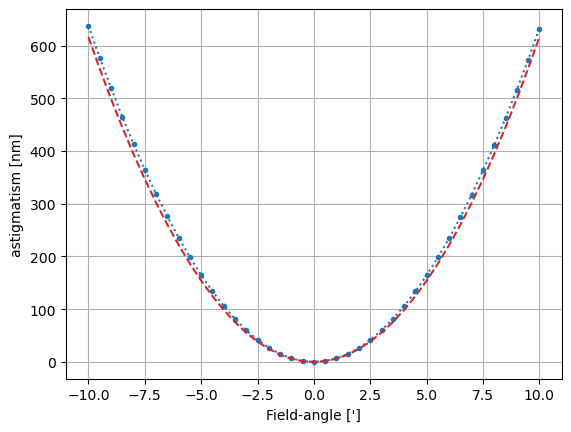

In [132]:
fig,ax = plt.subplots()
ax.plot(z,astigmatism,'.:')
#ax.plot(z,np.polyval(p_astigmatism,z),'k:')
ax.plot(z,c222*z**2,'C3--')
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("astigmatism [nm]")
ax.grid()

In [94]:
p_coma,p_spherical

(array([-0.0067454 , -0.02269945,  0.39980295, -0.16057522]),
 array([ 0.00337162, -0.0112129 ,  0.04180062]))

In [95]:
p_coma,p_spherical

(array([-0.0067454 , -0.02269945,  0.39980295, -0.16057522]),
 array([ 0.00337162, -0.0112129 ,  0.04180062]))

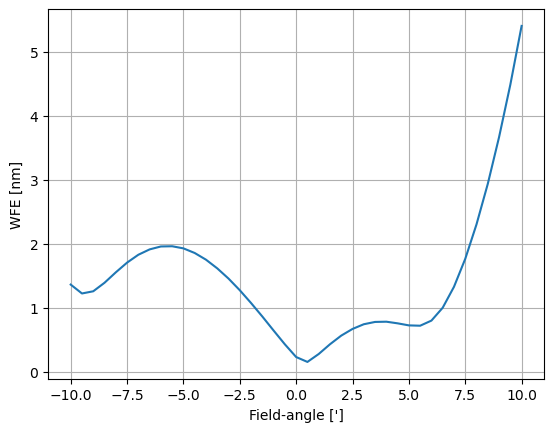

In [96]:
wfe = np.asarray([np.sqrt(np.sum(np.asarray(x[1][7:])**2)) for x in data] )
fig,ax = plt.subplots()
ax.plot(z,wfe)
#ax.set_xticks(np.arange(-10,11))
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("WFE [nm]")
ax.grid()

In [97]:
np.cos(-np.pi/6),np.sqrt(3)/2

(0.8660254037844387, 0.8660254037844386)

In [98]:
coma240 = g**4 * 0.04353 *4 / ((180*60/np.pi)**2*1e-9*np.sqrt(8))
coma240

0.06089074009271809

In [99]:
p_coma[1]/coma240

-0.3727898923217222

In [100]:
2*np.cos(np.pi/6),np.sin(np.pi/6)

(1.7320508075688774, 0.49999999999999994)

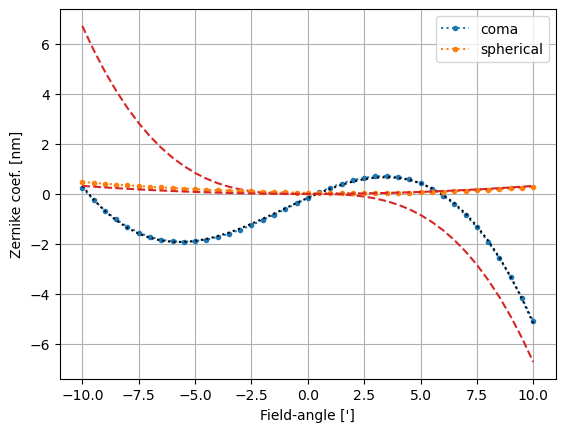

In [101]:
fig,ax = plt.subplots()
ax.plot(z,coma,'.:',label="coma")
ax.plot(z,np.polyval(p_coma,z),'k:')
ax.plot(z,c331*z**3 + c131*z,'C3--')
#ax.plot(z,c331*z**3 + c131*z + coma240*z**2,'C4--')
ax.plot(z,spherical,'.:',label="spherical")
ax.plot(z,c240*z**2 ,'C3--')
#ax.plot(z,np.polyval(p_spherical,z),'k:')
#ax.plot(z,np.polyval(p_quadrafoil,z),'k:')
#ax.plot(z,quadrafoil,'.',label="quadrafoil")
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("Zernike coef. [nm]")
ax.grid()
ax.legend()

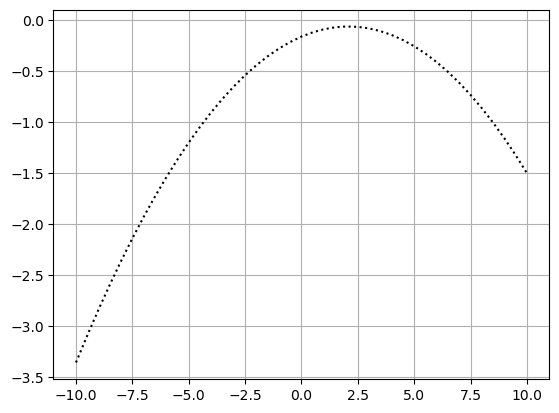

In [39]:
fig,ax = plt.subplots()
#ax.plot(z,coma,'.:',label="coma")
ax.plot(z,np.polyval(p_coma,z)-c331*z**3 - c131*z,'k:')
ax.grid()
#ax.plot(z,c331*z**3 + c131*z,'C3--')

In [77]:
p_trefoil

array([-1.44158919e-04, -1.17788268e-05,  1.77976646e-05,  1.14809420e-04])

In [234]:
p_coma_s3[1]*(180*60/np.pi)**2*1e-9*0.25*np.sqrt(8)/g**4/(s*np.sin(-np.pi/6))

-0.02029138856394243

In [252]:
z[0]

-10.0

In [253]:
i = 0
sids = np.arange(1,8)
data = [np.load(f"field-aberrations_s{sid}_lsq.pkl",allow_pickle=True) for sid in sids]
a5 = [d[i][1][4] for d in data]
a6 = [d[i][1][5] for d in data]
a7 = [d[i][1][6] for d in data]
a8 = [d[i][1][7] for d in data]

In [295]:
def fifth_order(h,p,s,p_s):
    g = 8.365/25.5
    return 1e9*np.array([g**2*0.5*h**2*np.cos(2*p),
              g**4*(1/8)*h**2*(3*np.cos(2*p)+4*s**2*np.cos(2*p)+32*s**2*np.cos(p+p_s)*np.cos(p-p_s)),
              g**3*2*h*s*np.cos(p+p_s),
              g**3*2*h**3*s*np.cos(p+p_s),
              g**4*12*h**2*s**2*np.cos(2*p_s)])/np.sqrt(6)
    

In [296]:
fifth_order(1,0,1,np.pi/2)

array([ 2.19657435e+07,  4.13652342e+06,  1.76486919e-09,  1.76486919e-09,
       -5.67294640e+07])

In [297]:
def fifth_order_matrix(h,p):
    s = 2*8.71/8.365
    return np.vstack([fifth_order(h,p,s,np.pi/2),
                      fifth_order(h,p,s,np.pi/6),
                      fifth_order(h,p,s,-np.pi/6),
                      fifth_order(h,p,s,-np.pi/2),
                      fifth_order(h,p,s,7*np.pi/6),
                      fifth_order(h,p,s,5*np.pi/6),    
                      fifth_order(h,p,0,0),    
                     ])

In [298]:
fifth_order_matrix(1,0)

array([[ 2.19657435e+07,  1.20236923e+07,  3.67531635e-09,
         3.67531635e-09, -2.46021516e+08],
       [ 2.19657435e+07,  7.35290714e+07,  5.19809847e+07,
         5.19809847e+07,  1.23010758e+08],
       [ 2.19657435e+07,  7.35290714e+07,  5.19809847e+07,
         5.19809847e+07,  1.23010758e+08],
       [ 2.19657435e+07,  1.20236923e+07,  3.67531635e-09,
         3.67531635e-09, -2.46021516e+08],
       [ 2.19657435e+07,  7.35290714e+07, -5.19809847e+07,
        -5.19809847e+07,  1.23010758e+08],
       [ 2.19657435e+07,  7.35290714e+07, -5.19809847e+07,
        -5.19809847e+07,  1.23010758e+08],
       [ 2.19657435e+07,  1.77279575e+06,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00]])

In [299]:
len(z)

41

In [300]:
a = np.vstack([fifth_order_matrix(x*np.pi/180/60,0) for x in z])

In [301]:
a.shape,a6.shape

((287, 5), (287,))

In [302]:
a6 = np.hstack([[d[i][1][5] for d in data] for i in range(len(z))])

In [303]:
w,res,r,s = np.linalg.lstsq(a,a6,rcond=None)

In [293]:
w,res,r,s

(array([-3.30539363e+00, -1.59360403e-04,  3.84107249e+01,  6.62811341e-03]),
 array([656.42215327]),
 4,
 array([1.14558301e+06, 1.08370174e+04, 1.47798825e+03, 2.65653220e+00]))

In [304]:
w,res,r,s

(array([-3.26332022e+00, -2.02203164e-02, -1.59360402e-04,  3.84107249e+01,
         9.99816614e-03]),
 array([60.97267854]),
 5,
 array([1.14558301e+06, 1.10014631e+04, 3.53877440e+03, 4.96491641e+02,
        2.65653220e+00]))

In [305]:
a@w

array([-6.29408482e+02, -6.33759736e+02, -6.33759736e+02, -6.29408482e+02,
       -5.83663313e+02, -5.83663313e+02, -6.06841067e+02, -5.68041155e+02,
       -5.68605938e+02, -5.68605938e+02, -5.68041155e+02, -5.30118364e+02,
       -5.30118364e+02, -5.47674063e+02, -5.09820871e+02, -5.07196008e+02,
       -5.07196008e+02, -5.09820871e+02, -4.78916662e+02, -4.78916662e+02,
       -4.91541264e+02, -4.54747629e+02, -4.49493086e+02, -4.49493086e+02,
       -4.54747629e+02, -4.30095067e+02, -4.30095067e+02, -4.38442671e+02,
       -4.02821429e+02, -3.95460315e+02, -3.95460315e+02, -4.02821429e+02,
       -3.83690436e+02, -3.83690436e+02, -3.88378283e+02, -3.54042271e+02,
       -3.45060836e+02, -3.45060836e+02, -3.54042271e+02, -3.39739629e+02,
       -3.39739629e+02, -3.41348100e+02, -3.08410156e+02, -2.98257791e+02,
       -2.98257791e+02, -3.08410156e+02, -2.98279503e+02, -2.98279503e+02,
       -2.97352123e+02, -2.65925084e+02, -2.55014322e+02, -2.55014322e+02,
       -2.65925084e+02, -

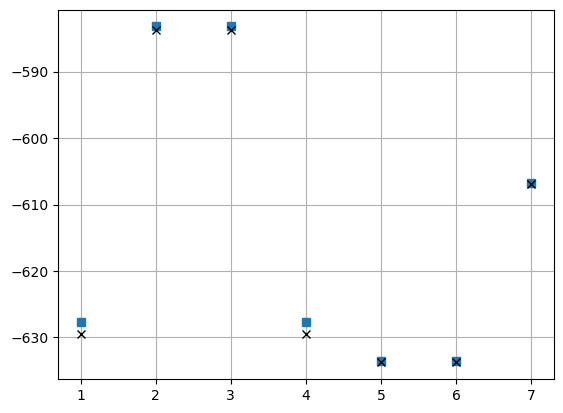

In [306]:
fig,ax = plt.subplots()
ax.plot(sids,a6[-7:],'s')
ax.plot(sids,(a@w)[-7:],'kx')
ax.grid()

In [28]:
a6[6]*3-a6[0],a6[1]+a6[4]

(-145128.9180464095, -153917.64911683783)

In [38]:
cst = 0.5*((a6[1]+a6[4])-(a6[6]*3-a6[0]))
cst

-4394.365535214165

In [40]:
0.5*(a6[1]-a6[4]),a6[1]-a6[6]-0.5*(a6[6]-a6[0])-cst,a6[2]-a6[6]-0.5*(a6[6]-a6[3])-cst

(3955.3801111523935, 3955.3801111523935, 3955.380061351607)

In [10]:
a6

[21006.756971033785,
 21453.290704256317,
 20903.936176857736,
 19343.44642458872,
 20903.93619038214,
 21453.290684244355,
 20072.822865509086]

In [5]:
a6

[-21484.43414128796,
 -19878.78895011062,
 -19878.788973122788,
 -21484.433789068702,
 -21159.759789386604,
 -21159.759875897547,
 -20110.148325785405]

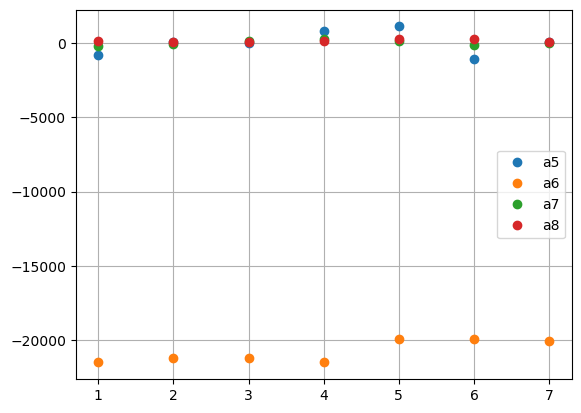

In [285]:
fig,ax= plt.subplots()
ax.plot(sids,a5,'o',label="a5")
ax.plot(sids,a6,'o',label="a6")
ax.plot(sids,a7,'o',label="a7")
ax.plot(sids,a8,'o',label="a8")
ax.grid()
ax.legend()

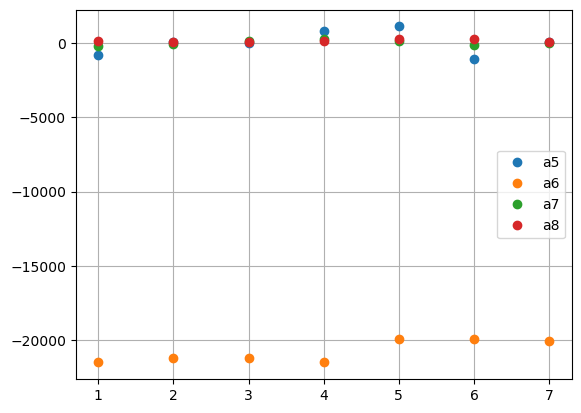

In [285]:
fig,ax= plt.subplots()
ax.plot(sids,a5,'o',label="a5")
ax.plot(sids,a6,'o',label="a6")
ax.plot(sids,a7,'o',label="a7")
ax.plot(sids,a8,'o',label="a8")
ax.grid()
ax.legend()

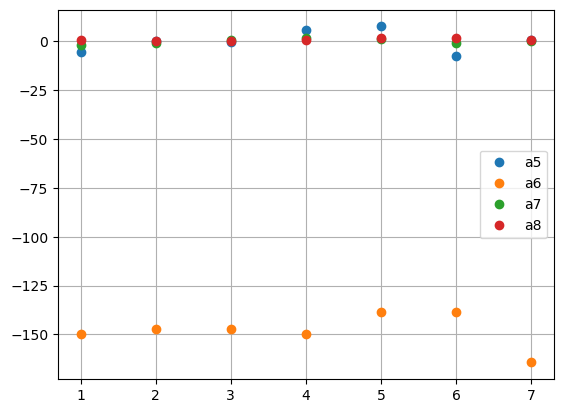

In [244]:
fig,ax= plt.subplots()
ax.plot(sids,a5,'o',label="a5")
ax.plot(sids,a6,'o',label="a6")
ax.plot(sids,a7,'o',label="a7")
ax.plot(sids,a8,'o',label="a8")
ax.grid()
ax.legend()

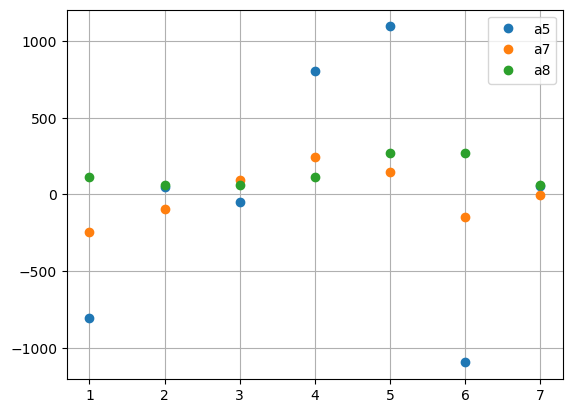

In [286]:
fig,ax= plt.subplots()
ax.plot(sids,a5,'o',label="a5")
#ax.plot(sids,a6,'o',label="a6")
ax.plot(sids,a7,'o',label="a7")
ax.plot(sids,a8,'o',label="a8")
ax.grid()
ax.legend()

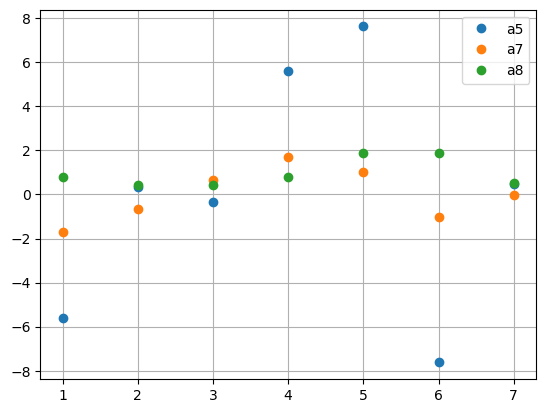

In [245]:
fig,ax= plt.subplots()
ax.plot(sids,a5,'o',label="a5")
#ax.plot(sids,a6,'o',label="a6")
ax.plot(sids,a7,'o',label="a7")
ax.plot(sids,a8,'o',label="a8")
ax.grid()
ax.legend()

In [246]:
0.5 * -2.96887 * g**2 * (z[i]*180*3600/np.pi)**2 * 1e-9

-170.7061380559012

In [247]:
s = 2*8.71/8.365
phi_s = np.pi/2-np.arange(6)*np.pi/3
s,phi_s*180/np.pi,np.cos(phi_s),np.cos(2*phi_s)

(2.082486551105798,
 array([  90.,   30.,  -30.,  -90., -150., -210.]),
 array([ 6.12323400e-17,  8.66025404e-01,  8.66025404e-01,  6.12323400e-17,
        -8.66025404e-01, -8.66025404e-01]),
 array([-1. ,  0.5,  0.5, -1. ,  0.5,  0.5]))

In [248]:
g

0.328812893081761

In [255]:
z_rd = z[i]*np.pi/180/60
w222 = 3.5
w131 = 0.00025
w331 = -65.19805
w240 = 0.04353
g = 8.365/25.44

In [256]:
a6_mdl_0 = 0.5 *g**2 * w222 * z_rd**2 * 1e9
a6_mdl_1 = np.zeros(7)
a6_mdl_1[:6] = 2 * s * np.cos(phi_s) * g**3 * (w131 * z_rd + w331 * z_rd**3) * 1e9
a6_mdl_1[6] = 0
a6_mdl_2 = np.zeros(7)
a6_mdl_2[:6] = 12 * s**2 * np.cos(2*phi_s) * g**4 * w240 * z_rd**2 * 1e9  * 0.7
a6_mdl_2[6] = 0
a6_mdl = (a6_mdl_0 + a6_mdl_1 + a6_mdl_2)/np.sqrt(6)

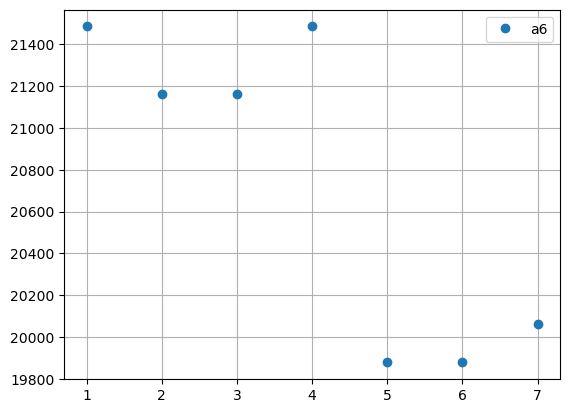

In [288]:
fig,ax= plt.subplots()
ax.plot(sids,-np.array(a6),'o',label="a6")
#ax.plot(sids,a6_mdl,'kx',label="a6")
ax.grid()
ax.legend()

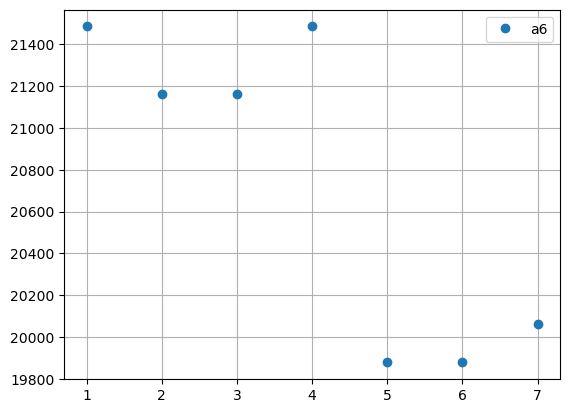

In [288]:
fig,ax= plt.subplots()
ax.plot(sids,-np.array(a6),'o',label="a6")
#ax.plot(sids,a6_mdl,'kx',label="a6")
ax.grid()
ax.legend()

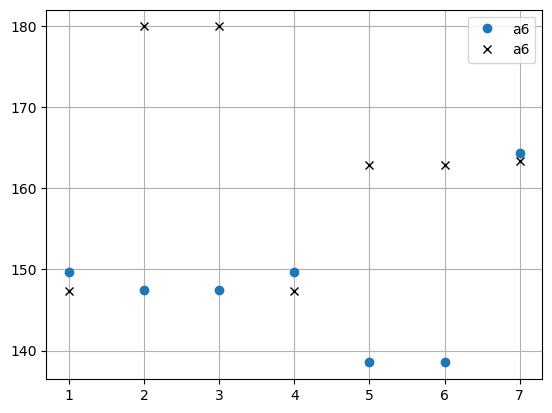

In [257]:
fig,ax= plt.subplots()
ax.plot(sids,-np.array(a6),'o',label="a6")
ax.plot(sids,a6_mdl,'kx',label="a6")
ax.grid()
ax.legend()

In [240]:
575/710

0.8098591549295775

In [278]:
s = 0.6*2*8.71/8.365

In [279]:
a5_mdl_0 = 0* 0.5 *g**2 * w222 * z_rd**2 * 1e9
a5_mdl_1 = np.zeros(7)
a5_mdl_1[:6] = 2 * s * np.sin(phi_s) * g**3 * (w131 * z_rd + w331 * z_rd**3) * 1e9
a5_mdl_1[6] = 0
a5_mdl_2 = np.zeros(7)
a5_mdl_2[:6] = 12 * s**2 * np.sin(2*phi_s) * g**4 * w240 * z_rd**2 * 1e9 
a5_mdl_2[6] = 0
a5_mdl = (a5_mdl_0 + a5_mdl_1 + a5_mdl_2)/np.sqrt(6)

In [280]:
a5_mdl_1

array([ 14.48220534,   7.24110267,  -7.24110267, -14.48220534,
        -7.24110267,   7.24110267,   0.        ])

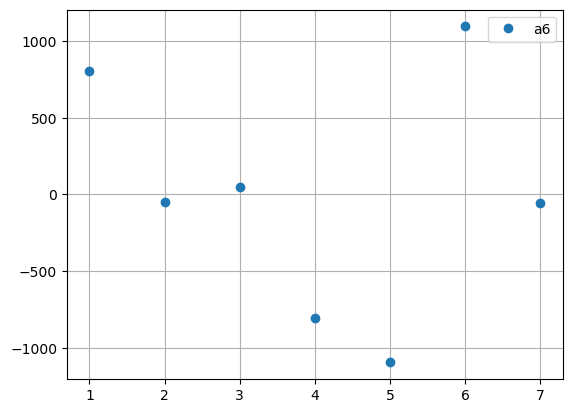

In [289]:
fig,ax= plt.subplots()
ax.plot(sids,-np.array(a5),'o',label="a6")
#ax.plot(sids,a5_mdl,'kx',label="a6")
ax.grid()
ax.legend()

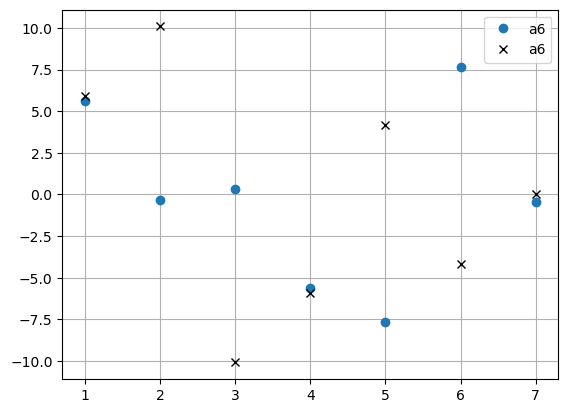

In [281]:
fig,ax= plt.subplots()
ax.plot(sids,-np.array(a5),'o',label="a6")
ax.plot(sids,a5_mdl,'kx',label="a6")
ax.grid()
ax.legend()